In [ ]:
from tensorflow.keras.layers import Conv2D
import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from src.green_gecko_model import CAModel, make_seed

# Calculating PCA variance explained
### Load model

In [2]:
#@title Cellular Automata Parameters
CHANNEL_N = 16        # Number of CA state channels
TARGET_PADDING = 16   # Number of pixels used to pad the target image border
TARGET_SIZE = 40
CELL_FIRE_RATE = 1. #0.5

# My own defined things
size = TARGET_SIZE + TARGET_PADDING * 2
x_start, y_start = TARGET_PADDING, TARGET_PADDING # size//2, size//2 # 
x_end, y_end =  TARGET_PADDING+TARGET_SIZE, TARGET_PADDING+TARGET_SIZE #size//2+1, size//2+1 #

In [3]:
model = CAModel(channel_n=CHANNEL_N, fire_rate=CELL_FIRE_RATE)
model.load_weights("model/plain_salamander/big_fire_rate1_nr3/8000.weights.h5")
None

2026-04-09 22:08:43.986300: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-09 22:08:43.986324: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-09 22:08:43.986331: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-09 22:08:43.986347: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-09 22:08:43.986357: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-09 22:08:44.287728: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


### Run model

In [4]:
seed = make_seed(TARGET_SIZE+TARGET_PADDING*2, n=1, channel_n=CHANNEL_N)
x = tf.convert_to_tensor(seed)

states = [tf.identity(x).numpy()]

for iter in range(3000):
    x = model(x)
    states.append(tf.identity(x).numpy())

states_np = np.stack(states)[:,:,x_start:x_end,y_start:y_end]

In [5]:
flattened_attractor_states = states_np.reshape(states_np.shape[0], -1)

### Do PCA and plot the cumulative sum

95% of the variance is explained by 17 components
And at this number of components, the ratio of variance explained is 0.9555389881134033


Text(0, 0.5, 'Ratio of variance explained')

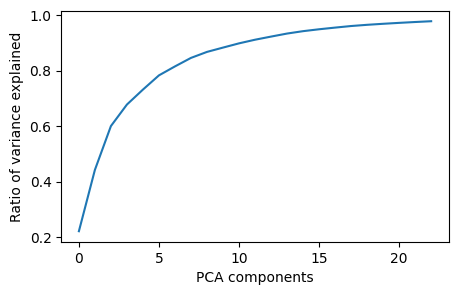

In [6]:
attractor_pca_no_scale = PCA(n_components=23)
pca_from_2000 = attractor_pca_no_scale.fit_transform(flattened_attractor_states[2000:]) # For the non-stochastic, it was 1000

cumulative_sum = np.cumsum(attractor_pca_no_scale.explained_variance_ratio_)

print("95% of the variance is explained by {} components".format(np.argmax(cumulative_sum > 0.95) + 1))
print("And at this number of components, the ratio of variance explained is {}".format(cumulative_sum[np.argmax(cumulative_sum > 0.95)]))

plt.figure(figsize=(5,3))
plt.plot(cumulative_sum)
plt.xlabel("PCA components")
plt.ylabel("Ratio of variance explained")

### And then for scaled data

In [7]:
scaler = StandardScaler()
scaler = scaler.fit(flattened_attractor_states[2000:]) # originally 2000
flattened_attractor_states_scaled = scaler.transform(flattened_attractor_states)

95% of the variance is explained by 32 components
And at this number of components, the ratio of variance explained is 0.9500699043273926


Text(0, 0.5, 'Ratio of variance explained')

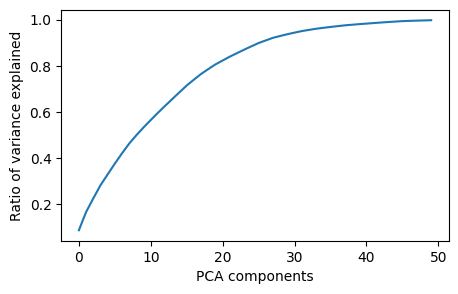

In [8]:
attractor_pca_ratio = PCA(n_components=50)
pca_from_2000 = attractor_pca_ratio.fit_transform(flattened_attractor_states_scaled[2000:])

cumulative_sum = np.cumsum(attractor_pca_ratio.explained_variance_ratio_)

print("95% of the variance is explained by {} components".format(np.argmax(cumulative_sum > 0.95) + 1))
print("And at this number of components, the ratio of variance explained is {}".format(cumulative_sum[np.argmax(cumulative_sum > 0.95)]))


plt.figure(figsize=(5,3))
plt.plot(cumulative_sum)
plt.xlabel("PCA components")
plt.ylabel("Ratio of variance explained")